In [18]:
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv(r"C:\Users\Pelin\Desktop\Yeni klasör\jm1.csv")


In [23]:
df.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            108

In [13]:
df.describe()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment
count,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,1.088500e+04,10885.000000,10885.000000,10885.00000,10885.000000
mean,42.016178,6.348590,3.401047,4.001599,114.389738,673.758017,0.135335,14.177237,29.439544,3.683637e+04,0.224766,2.046465e+03,26.252274,2.737529,4.62554,0.370785
std,76.593332,13.019695,6.771869,9.116889,249.502091,1938.856196,0.160538,18.709900,34.418313,4.343678e+05,0.646408,2.413154e+04,59.611201,9.008608,9.96813,1.907969
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.860000,1.619400e+02,0.020000,9.000000e+00,4.000000,0.000000,0.00000,0.000000
50%,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.930000,2.031020e+03,0.070000,1.128300e+02,13.000000,0.000000,2.00000,0.000000
75%,46.000000,7.000000,3.000000,4.000000,119.000000,621.480000,0.160000,18.900000,36.780000,1.141643e+04,0.210000,6.342500e+02,28.000000,2.000000,5.00000,0.000000
max,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.780000,3.107978e+07,26.950000,1.726655e+06,2824.000000,344.000000,447.00000,108.000000


In [14]:
df.isnull().sum()

loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [24]:
df["defects"] = df["defects"].astype(int)

# Convert 'defects' column from boolean (True/False) to binary (1/0) 
# This prepares the target variable for machine learning models


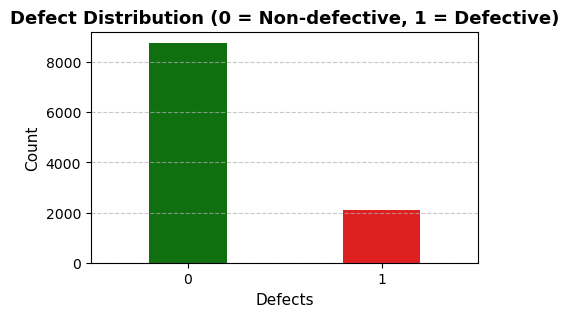

In [74]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,3))

sns.countplot(x=df['defects'].astype(str), 
              palette=['green', 'red'], 
              width=0.4)

plt.title('Defect Distribution (0 = Non-defective, 1 = Defective)', fontsize=13, fontweight='bold')
plt.xlabel('Defects', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




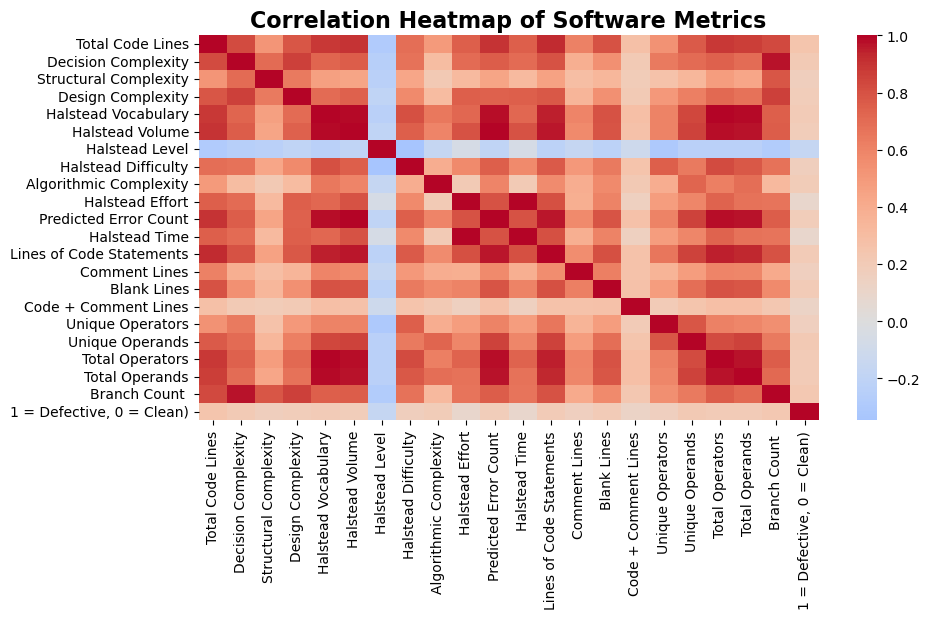

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numeric_df = df.select_dtypes(include=['int64', 'float64'])

metric_desc = {
    'loc': 'Total Code Lines',
    'v(g)': 'Decision Complexity',
    'ev(g)': 'Structural Complexity',
    'iv(g)': 'Design Complexity',
    'n': 'Halstead Vocabulary',
    'v': 'Halstead Volume',
    'l': 'Halstead Level',
    'd': 'Halstead Difficulty',
    'i': 'Algorithmic Complexity',
    'e': 'Halstead Effort',
    'b': 'Predicted Error Count',
    't': 'Halstead Time',
    'lOCode': 'Lines of Code Statements',
    'lOComment': 'Comment Lines',
    'lOBlank': 'Blank Lines',
    'locCodeAndComment': 'Code + Comment Lines',
    'uniq_Op': 'Unique Operators',
    'uniq_Opnd': 'Unique Operands',
    'total_Op': 'Total Operators',
    'total_Opnd': 'Total Operands',
    'branchCount': 'Branch Count ',
    'defects': '1 = Defective, 0 = Clean)'
}

corr = numeric_df.corr()

corr = corr.rename(index=metric_desc, columns=metric_desc)

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr,
    annot=False,     
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Software Metrics', fontsize=16, fontweight='bold')
plt.show()

╒═════════════╤════════════════════════════════╤════════════════════════════╕
│ Metric      │ Description                    │  Correlation with Defects  │
╞═════════════╪════════════════════════════════╪════════════════════════════╡
│ loc         │ Lines of Code                  │           0.245            │
├─────────────┼────────────────────────────────┼────────────────────────────┤
│ branchCount │ Branch Count (Decision Points) │           0.222            │
├─────────────┼────────────────────────────────┼────────────────────────────┤
│ uniq_Opnd   │ Unique Operands                │           0.212            │
├─────────────┼────────────────────────────────┼────────────────────────────┤
│ v(g)        │ Cyclomatic Complexity          │           0.209            │
├─────────────┼────────────────────────────────┼────────────────────────────┤
│ n           │ Program Size                   │           0.204            │
├─────────────┼────────────────────────────────┼────────────────

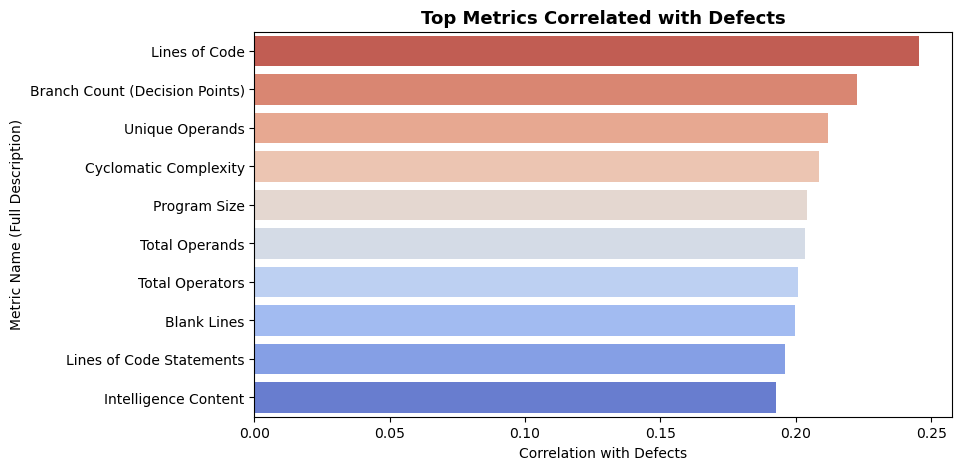

In [75]:
import warnings
warnings.filterwarnings("ignore")
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


obj_cols = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']
for c in obj_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')  
df[obj_cols] = df[obj_cols].fillna(df[obj_cols].median())

corr_with_defects = df.corr(numeric_only=True)['defects'].drop('defects').sort_values(ascending=False)

metric_desc = {
    'loc': 'Lines of Code',
    'branchCount': 'Branch Count (Decision Points)',
    'uniq_Op': 'Unique Operators',
    'uniq_Opnd': 'Unique Operands',
    'total_Op': 'Total Operators',
    'total_Opnd': 'Total Operands',
    'v(g)': 'Cyclomatic Complexity',
    'i': 'Intelligence Content',
    'n': 'Program Size',
    'd': 'Difficulty Level',
    'lOCode': 'Lines of Code Statements',
    'lOBlank': 'Blank Lines'
}

table_data = []
for metric, corr in corr_with_defects.head(10).items():
    desc = metric_desc.get(metric, "N/A")
    table_data.append([metric, desc, round(corr, 3)])

print(tabulate(
    table_data,
    headers=[
        "\033[1mMetric\033[0m", "\033[1mDescription\033[0m","\033[1mCorrelation with Defects\033[0m"
    ],
    tablefmt="fancy_grid",
    colalign=("left", "left", "center")
))


corr_named = corr_with_defects.rename(index=metric_desc)

plt.figure(figsize=(9,5))
sns.barplot(
    x=corr_named.values[:10],
    y=corr_named.index[:10],
    palette='coolwarm_r'
)
plt.title("Top Metrics Correlated with Defects", fontsize=13, fontweight='bold')
plt.xlabel("Correlation with Defects")
plt.ylabel("Metric Name (Full Description)")
plt.show()



In [ ]:
from tabulate import tabulate

metric_desc = {
    'loc': 'Lines of Code',
    'v(g)': 'Cyclomatic Complexity',
    'ev(g)': 'Essential Complexity',
    'iv(g)': 'Design Complexity',
    'n': 'Program Vocabulary',
    'v': 'Halstead Volume',
    'l': 'Halstead Level',
    'd': 'Difficulty Level',
    'i': 'Intelligence Content',
    'e': 'Development Effort',
    'b': 'Estimated Bugs',
    't': 'Halstead Time',
    'lOCode': 'Code Lines',
    'lOComment': 'Comment Lines',
    'lOBlank': 'Blank Lines',
    'locCodeAndComment': 'Code + Comment Lines',
    'uniq_Op': 'Unique Operators',
    'uniq_Opnd': 'Unique Operands',
    'total_Op': 'Total Operators',
    'total_Opnd': 'Total Operands',
    'branchCount': 'Branch Count (Decision Points)'
}

mean_comparison = df.groupby('defects').mean(numeric_only=True).T

table_data = []
for metric, values in mean_comparison.iterrows():
    desc = metric_desc.get(metric, "N/A")
    table_data.append([metric, desc, round(values[0], 2), round(values[1], 2)])

print(tabulate(
    table_data,
    headers=["\033[1mMetric\033[0m", 
             "\033[1mDescription\033[0m", 
             "\033[1mNot Bug (0)\033[0m", 
             "\033[1mBug (1)\033[0m"],
    tablefmt="fancy_grid",
    colalign=("left", "left", "center", "center")
))


╒═══════════════════╤════════════════════════════════╤═══════════════╤═══════════╕
│ Metric            │ Description                    │  Not Bug (0)  │  Bug (1)  │
╞═══════════════════╪════════════════════════════════╪═══════════════╪═══════════╡
│ loc               │ Lines of Code                  │     32.81     │   80.39   │
├───────────────────┼────────────────────────────────┼───────────────┼───────────┤
│ v(g)              │ Cyclomatic Complexity          │     5.02      │   11.89   │
├───────────────────┼────────────────────────────────┼───────────────┼───────────┤
│ ev(g)             │ Essential Complexity           │     2.83      │   5.79    │
├───────────────────┼────────────────────────────────┼───────────────┼───────────┤
│ iv(g)             │ Design Complexity              │     3.19      │   7.39    │
├───────────────────┼────────────────────────────────┼───────────────┼───────────┤
│ n                 │ Program Vocabulary             │     89.44     │  218.38   │
├───

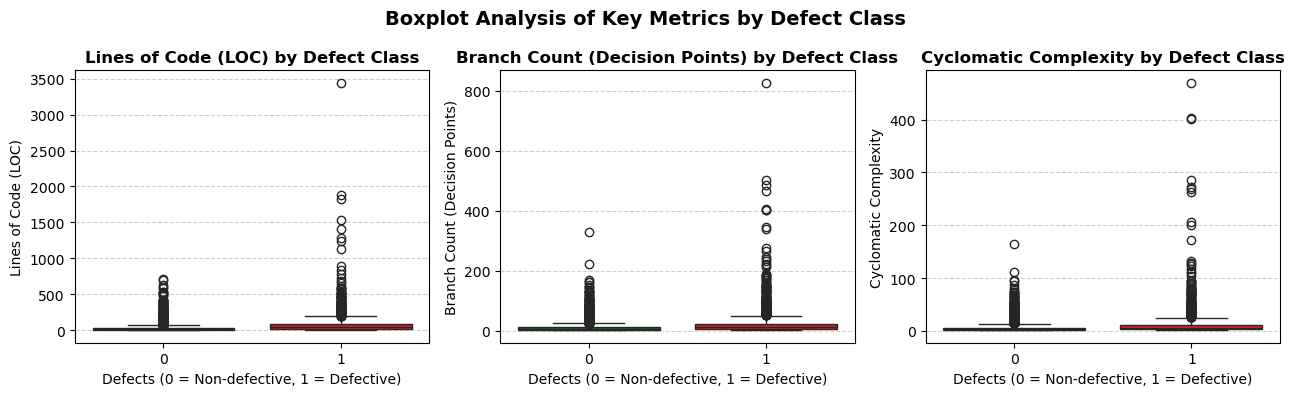

In [49]:

df["defects_str"] = df["defects"].astype(int).astype(str)

import matplotlib.pyplot as plt
import seaborn as sns

metric_names = {
    'loc': 'Lines of Code (LOC)',
    'branchCount': 'Branch Count (Decision Points)',
    'v(g)': 'Cyclomatic Complexity'
}

metrics = ['loc', 'branchCount', 'v(g)']
plt.figure(figsize=(13,4))

for i, m in enumerate(metrics, 1):
    plt.subplot(1,3,i)
    sns.boxplot(
        data=df, x="defects_str", y=m,
        hue="defects_str", palette={'0':'green','1':'red'}, legend=False
    )
    
    plt.title(f'{metric_names[m]} by Defect Class', fontsize=12, fontweight='bold')
    plt.xlabel('Defects (0 = Non-defective, 1 = Defective)')
    plt.ylabel(metric_names[m])
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Boxplot Analysis of Key Metrics by Defect Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [37]:
pip install tabulate


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [63]:
from tabulate import tabulate
import pandas as pd
import numpy as np

metric_descriptions = {
    'loc': 'Lines of Code',
    'branchCount': 'Branch Count (Number of decision points)',
    'v(g)': 'Cyclomatic Complexity',
    'total_Op': 'Total Operators',
    'total_Opnd': 'Total Operands',
    'i': 'Intelligence Content',
    'd': 'Difficulty Level'
}

metrics = list(metric_descriptions.keys())
summary = []

for m in metrics:
    Q1 = df[m].quantile(0.25)
    Q3 = df[m].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = max(0, Q1 - 1.5 * IQR)
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[m] < lower_bound) | (df[m] > upper_bound)].shape[0]

    summary.append([
        f"{m} ({metric_descriptions[m]})",   
        outlier_count,
        f"{lower_bound:.2f}",
        f"{upper_bound:.2f}"
    ])

print(tabulate(
    summary,
    headers=[
        "\033[1mMetric (Description)\033[0m","\033[1mOutlier Count\033[0m","\033[1mLower Bound\033[0m","\033[1mUpper Bound\033[0m"
    ],
    tablefmt="fancy_grid",
    colalign=("left", "center", "right", "right")
))



╒════════════════════════════════════════════════════════╤═════════════════╤═══════════════╤═══════════════╕
│ Metric (Description)                                   │  Outlier Count  │   Lower Bound │   Upper Bound │
╞════════════════════════════════════════════════════════╪═════════════════╪═══════════════╪═══════════════╡
│ loc (Lines of Code)                                    │       964       │             0 │          98.5 │
├────────────────────────────────────────────────────────┼─────────────────┼───────────────┼───────────────┤
│ branchCount (Branch Count (Number of decision points)) │       918       │             0 │            28 │
├────────────────────────────────────────────────────────┼─────────────────┼───────────────┼───────────────┤
│ v(g) (Cyclomatic Complexity)                           │       954       │             0 │          14.5 │
├────────────────────────────────────────────────────────┼─────────────────┼───────────────┼───────────────┤
│ total_Op (Total O

In [55]:
import os
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/jm1_clean.csv", index=False)

In [54]:
df.to_csv("data/processed/jm1_clean.csv", index=False)
